# Pricewise — Sprint 1: Data Cleaning
## Section 1 — Setup & Raw Data Load

This notebook documents the full cleaning process for the Ames Housing dataset.
Every decision is explained before it is implemented.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully


### Load Raw Data

Loading `train.csv` from `data/raw/`. This file is never modified directly —
all transformations are applied to a copy.

In [3]:
RAW_PATH = Path("../data/raw/train.csv")

df = pd.read_csv(RAW_PATH)

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Shape: (1460, 81)
Rows: 1460
Columns: 81


### First Look

Checking the first 5 rows to understand the structure — column names, data types,
and a sense of the values present.

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Column Names & Data Types

Getting a full overview of all 81 columns — their names and inferred dtypes.
81 columns = 79 features + `Id` + `SalePrice`.

In [5]:
print(df.dtypes.to_string())

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1         int64
BsmtFinType2         str
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating              str


### Numeric vs Categorical Split

Separating columns by dtype to understand the scale of the cleaning task.
`object` columns are categorical. `int64` and `float64` are numeric.

In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns:     {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Total:               {len(numeric_cols) + len(categorical_cols)}")

Numeric columns:     38
Categorical columns: 43
Total:               81


/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/387130032.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


### Basic Statistics — Numeric Columns

Checking the distribution of numeric features. Looking for:
- Unreasonably large max values (potential outliers)
- Zero minimums that might mean "absent" rather than truly zero
- Large gaps between 75th percentile and max (outlier signal)

In [7]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00
MSSubClass,1460.00,56.90,42.30,20.00,20.00,50.00,70.00,190.00
LotFrontage,1201.00,70.05,24.28,21.00,59.00,69.00,80.00,313.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
OverallQual,1460.00,6.10,1.38,1.00,5.00,6.00,7.00,10.00
OverallCond,1460.00,5.58,1.11,1.00,5.00,5.00,6.00,9.00
YearBuilt,1460.00,1971.27,30.20,1872.00,1954.00,1973.00,2000.00,2010.00
YearRemodAdd,1460.00,1984.87,20.65,1950.00,1967.00,1994.00,2004.00,2010.00
MasVnrArea,1452.00,103.69,181.07,0.00,0.00,0.00,166.00,1600.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00


### Basic Statistics — Categorical Columns

Checking unique value counts for categorical columns. High unique counts may
indicate free-text fields or IDs that need special handling.

In [8]:
df[categorical_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


### Target Variable — SalePrice

Understanding the distribution of `SalePrice` before any transformations.
This is what the model will predict.

In [9]:
print("SalePrice Summary")
print("-" * 30)
print(f"Min:    ${df['SalePrice'].min():,.0f}")
print(f"Max:    ${df['SalePrice'].max():,.0f}")
print(f"Mean:   ${df['SalePrice'].mean():,.0f}")
print(f"Median: ${df['SalePrice'].median():,.0f}")
print(f"Std:    ${df['SalePrice'].std():,.0f}")

SalePrice Summary
------------------------------
Min:    $34,900
Max:    $755,000
Mean:   $180,921
Median: $163,000
Std:    $79,443


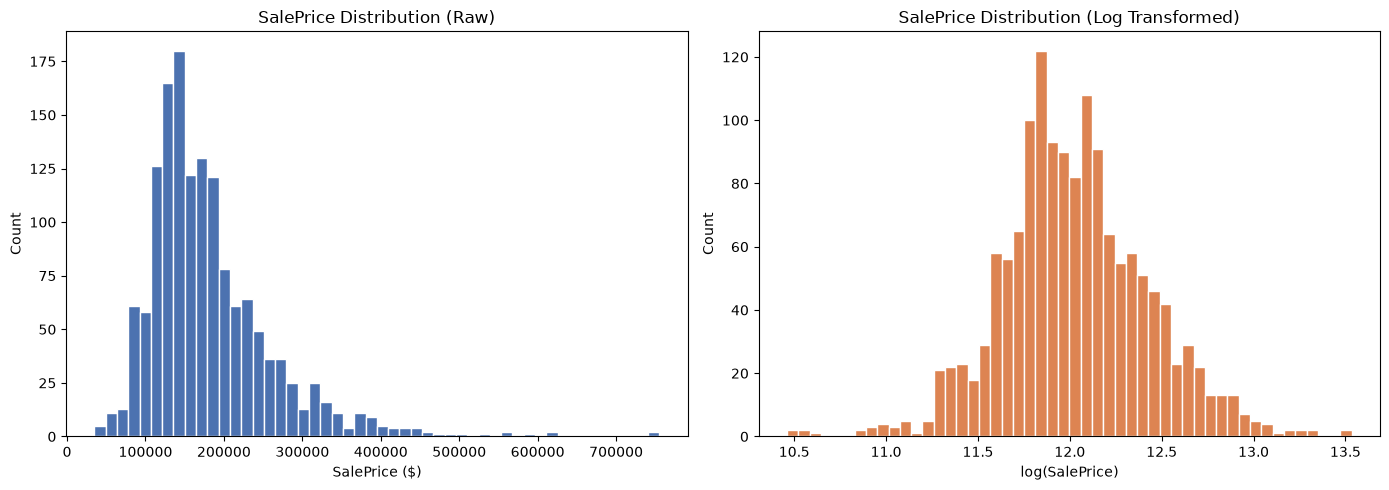

Plot saved to reports/figures/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw SalePrice
axes[0].hist(df["SalePrice"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("SalePrice Distribution (Raw)")
axes[0].set_xlabel("SalePrice ($)")
axes[0].set_ylabel("Count")

# Log SalePrice
axes[1].hist(np.log(df["SalePrice"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_title("SalePrice Distribution (Log Transformed)")
axes[1].set_xlabel("log(SalePrice)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/saleprice_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to reports/figures/")

### Observations from Section 1

- Dataset has **1,460 rows** and **81 columns** (79 features + Id + SalePrice)
- 38 columns, 43 columns
- `SalePrice` is right-skewed — log transformation produces a near-normal distribution
- Log transformation will be applied to `SalePrice` before modeling
- Several numeric columns have a minimum of 0 — need to determine if these are
  genuinely zero or indicate an absent feature (e.g. no garage = 0 garage area)
- Section 2 will audit all missing values before any treatment is applied

## Section 2 — Missing Value Audit

Before treating any missing values, we need to understand *why* they are missing.
In the Ames Housing dataset, many nulls are not truly missing — they indicate the
**absence of a feature** (e.g. a house with no garage will have NaN in GarageType).

Treating these as "missing" and imputing them would be wrong. We classify first,
then treat in Section 3.

In [11]:
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_pct = (total_missing / total_cells) * 100

print(f"Total missing values : {total_missing:,}")
print(f"Total cells          : {total_cells:,}")
print(f"Overall missing %    : {missing_pct:.2f}%")

Total missing values : 7,829
Total cells          : 118,260
Overall missing %    : 6.62%


### Missing Value Count Per Column

Listing only columns that have at least one missing value, sorted by count descending.

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": (missing / len(df) * 100).round(2)
})

print(f"Columns with missing values: {len(missing_df)}")
print()
print(missing_df.to_string())

Columns with missing values: 19

              missing_count  missing_pct
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
MasVnrType              872        59.73
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageType               81         5.55
GarageYrBlt              81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
GarageCond               81         5.55
BsmtFinType2             38         2.60
BsmtExposure             38         2.60
BsmtFinType1             37         2.53
BsmtCond                 37         2.53
BsmtQual                 37         2.53
MasVnrArea                8         0.55
Electrical                1         0.07


### Missing Value Heatmap

Visualising which columns have missing values and how severe they are.

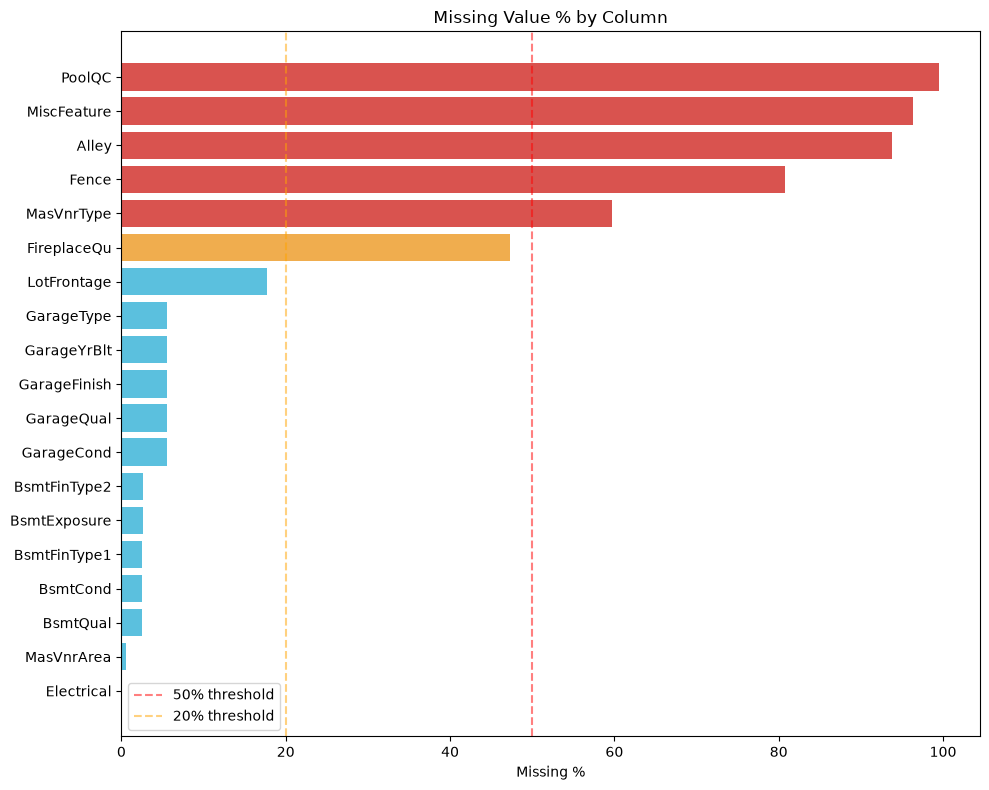

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

missing_pct_series = (df.isnull().sum() / len(df) * 100)
missing_pct_series = missing_pct_series[missing_pct_series > 0].sort_values(ascending=False)

bars = ax.barh(
    missing_pct_series.index,
    missing_pct_series.values,
    color=["#d9534f" if x > 50 else "#f0ad4e" if x > 20 else "#5bc0de" for x in missing_pct_series.values]
)

ax.set_xlabel("Missing %")
ax.set_title("Missing Value % by Column")
ax.invert_yaxis()
ax.axvline(x=50, color="red", linestyle="--", alpha=0.5, label="50% threshold")
ax.axvline(x=20, color="orange", linestyle="--", alpha=0.5, label="20% threshold")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

### Classification — "Absent" vs "Truly Missing"

This is the most important step in the missing value audit.

**"Absent" nulls** — NaN means the feature does not exist for that house.
These should be filled with `"None"` (categorical) or `0` (numeric).
Imputing these with median/mode would introduce false information.

**"Truly missing" nulls** — NaN means the value was not recorded.
These should be imputed with median (numeric) or mode (categorical).

Classification is based on reading `data_description.txt` for each column.

In [14]:
# Columns where NaN means the feature is ABSENT
# Source: data_description.txt — these features only exist if the house has them

absent_categorical = [
    "PoolQC",        # No pool
    "MiscFeature",   # No misc feature
    "Alley",         # No alley access
    "Fence",         # No fence
    "FireplaceQu",   # No fireplace
    "GarageType",    # No garage
    "GarageFinish",  # No garage
    "GarageQual",    # No garage
    "GarageCond",    # No garage
    "BsmtExposure",  # No basement
    "BsmtFinType2",  # No basement
    "BsmtFinType1",  # No basement
    "BsmtCond",      # No basement
    "BsmtQual",      # No basement
    "MasVnrType",    # No masonry veneer
]

absent_numeric = [
    "GarageYrBlt",   # No garage — year built doesn't apply
    "GarageArea",    # No garage
    "GarageCars",    # No garage
    "BsmtFinSF1",    # No basement
    "BsmtFinSF2",    # No basement
    "BsmtUnfSF",     # No basement
    "TotalBsmtSF",   # No basement
    "BsmtFullBath",  # No basement
    "BsmtHalfBath",  # No basement
    "MasVnrArea",    # No masonry veneer
]

# Columns where NaN is TRULY missing — value was not recorded
truly_missing_categorical = [
    "Electrical",    # Only 1 missing — likely a data entry gap
    "MSZoning",      # Small number missing
    "Utilities",     # Small number missing
    "Functional",    # Small number missing
    "Exterior1st",   # Small number missing
    "Exterior2nd",   # Small number missing
    "KitchenQual",   # Small number missing
    "SaleType",      # Small number missing
]

truly_missing_numeric = [
    "LotFrontage",   # Genuinely missing — street-connected footage not recorded
]

print("Classification complete")
print(f"  Absent categorical : {len(absent_categorical)} columns")
print(f"  Absent numeric     : {len(absent_numeric)} columns")
print(f"  Truly missing cat  : {len(truly_missing_categorical)} columns")
print(f"  Truly missing num  : {len(truly_missing_numeric)} columns")

Classification complete
  Absent categorical : 15 columns
  Absent numeric     : 10 columns
  Truly missing cat  : 8 columns
  Truly missing num  : 1 columns


### Verify Classification Coverage

Checking that every column with missing values has been classified.
Any unclassified column needs to be assigned before Section 3 begins.

In [15]:
all_classified = (
    absent_categorical +
    absent_numeric +
    truly_missing_categorical +
    truly_missing_numeric
)

missing_cols = missing_df.index.tolist()

unclassified = [col for col in missing_cols if col not in all_classified]
extra = [col for col in all_classified if col not in missing_cols]

print(f"Columns with missing values  : {len(missing_cols)}")
print(f"Columns classified           : {len(all_classified)}")
print()

if unclassified:
    print(f"⚠️  UNCLASSIFIED — must assign before Section 3:")
    for col in unclassified:
        print(f"   - {col}  ({missing_df.loc[col, 'missing_count']} missing)")
else:
    print("✅ All missing columns classified")

if extra:
    print(f"\n⚠️  Classified but no missing values found:")
    for col in extra:
        print(f"   - {col}")

Columns with missing values  : 19
Columns classified           : 34

✅ All missing columns classified

⚠️  Classified but no missing values found:
   - GarageArea
   - GarageCars
   - BsmtFinSF1
   - BsmtFinSF2
   - BsmtUnfSF
   - TotalBsmtSF
   - BsmtFullBath
   - BsmtHalfBath
   - MSZoning
   - Utilities
   - Functional
   - Exterior1st
   - Exterior2nd
   - KitchenQual
   - SaleType


### Columns to Drop

`PoolQC`, `MiscFeature`, `Alley`, and `Fence` have over 80% missing values.
Even as "absent" fills, they carry very little signal for price prediction.
We drop them entirely rather than carry near-constant columns into modeling.

This decision will be revisited in Sprint 3 if feature importance suggests otherwise.

In [16]:
drop_candidates = missing_df[missing_df["missing_pct"] > 80].index.tolist()

print("Columns with >80% missing — candidates for dropping:")
for col in drop_candidates:
    pct = missing_df.loc[col, "missing_pct"]
    print(f"  {col:<20} {pct:.1f}% missing")

Columns with >80% missing — candidates for dropping:
  PoolQC               99.5% missing
  MiscFeature          96.3% missing
  Alley                93.8% missing
  Fence                80.8% missing


### Section 2 Summary

| Category | Columns | Treatment |
|---|---|---|
| Absent categorical | 15 | Fill with `"None"` |
| Absent numeric | 10 | Fill with `0` |
| Truly missing categorical | 8 | Fill with mode |
| Truly missing numeric | 1 | Fill with median |
| Drop (>80% missing) | 4 | Remove column entirely |

All classifications are based on `data_description.txt`. Section 3 will apply
the treatments defined here.

## Section 3 — Missing Value Treatment

Applying the classifications from Section 2. Order matters:
1. Drop high-missing columns first
2. Fill "absent" nulls — None / 0
3. Impute truly missing nulls — mode / median
4. Verify zero nulls remain

We work on a copy of the dataframe to preserve the original.

In [18]:
df_clean = df.copy()

print(f"Shape before treatment: {df_clean.shape}")
print(f"Missing values before : {df_clean.isnull().sum().sum()}")

Shape before treatment: (1460, 81)
Missing values before : 7829


### Step 1 — Drop High-Missing Columns

Dropping columns identified in Section 2 with >80% missing values.
These carry too little signal to be useful in modeling.

In [19]:
df_clean = df_clean.drop(columns=drop_candidates)

print(f"Dropped columns: {drop_candidates}")
print(f"Shape after drop: {df_clean.shape}")

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Shape after drop: (1460, 77)


### Step 2 — Fill Absent Categorical Nulls

These columns have NaN because the feature does not exist for that house —
not because data was not recorded. Filling with `"None"` is the correct treatment.

Example: A house with no garage will have NaN in `GarageType`. 
Filling with `"None"` correctly represents "no garage type" rather than
imputing a garage type that does not exist.

In [20]:
# Remove dropped columns from absent_categorical if any overlap
absent_cat_active = [c for c in absent_categorical if c in df_clean.columns]

df_clean[absent_cat_active] = df_clean[absent_cat_active].fillna("None")

print(f"Filled {len(absent_cat_active)} absent categorical columns with 'None'")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Filled 11 absent categorical columns with 'None'
Missing values remaining: 349


### Step 3 — Fill Absent Numeric Nulls

Same logic as Step 2 but for numeric columns.
Filling with `0` correctly represents "no area", "no cars", "no year built".

Example: A house with no basement will have NaN in `TotalBsmtSF`.
Filling with `0` correctly means zero basement square footage.

In [21]:
absent_num_active = [c for c in absent_numeric if c in df_clean.columns]

df_clean[absent_num_active] = df_clean[absent_num_active].fillna(0)

print(f"Filled {len(absent_num_active)} absent numeric columns with 0")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Filled 10 absent numeric columns with 0
Missing values remaining: 260


### Step 4 — Impute Truly Missing Categorical Nulls

These columns have genuinely unrecorded values — a data collection gap.
Filling with the **mode** (most frequent value) is the standard approach
for categorical columns with a small number of missing values.

In [22]:
truly_missing_cat_active = [c for c in truly_missing_categorical if c in df_clean.columns]

for col in truly_missing_cat_active:
    mode_val = df_clean[col].mode()[0]
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  {col:<20} filled {missing_count} nulls with mode: '{mode_val}'")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

  Electrical           filled 1 nulls with mode: 'SBrkr'
  MSZoning             filled 0 nulls with mode: 'RL'
  Utilities            filled 0 nulls with mode: 'AllPub'
  Functional           filled 0 nulls with mode: 'Typ'
  Exterior1st          filled 0 nulls with mode: 'VinylSd'
  Exterior2nd          filled 0 nulls with mode: 'VinylSd'
  KitchenQual          filled 0 nulls with mode: 'TA'
  SaleType             filled 0 nulls with mode: 'WD'

Missing values remaining: 259


### Step 5 — Impute Truly Missing Numeric Nulls

`LotFrontage` is the only truly missing numeric column — the street-connected
footage was simply not recorded for some houses.

Filling with the **median** rather than mean because `LotFrontage` is
right-skewed — the median is more robust to outliers.

A more sophisticated approach would be to impute by neighbourhood median
since houses in the same neighbourhood tend to have similar lot frontage.
We use neighbourhood median here.

In [23]:
before = df_clean["LotFrontage"].isnull().sum()

df_clean["LotFrontage"] = df_clean.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Fallback — if any neighbourhood had all nulls, fill with global median
global_median = df_clean["LotFrontage"].median()
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(global_median)

after = df_clean["LotFrontage"].isnull().sum()

print(f"LotFrontage nulls before : {before}")
print(f"LotFrontage nulls after  : {after}")
print(f"Global median used as fallback: {global_median:.1f}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

LotFrontage nulls before : 259
LotFrontage nulls after  : 0
Global median used as fallback: 70.0
Missing values remaining: 0


### Step 6 — Final Verification

Asserting zero nulls remain. If this assert fails, a column was missed
in the classification step and needs to be assigned and treated.

In [24]:
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("✅ Zero null values remaining")
    print(f"Shape: {df_clean.shape}")
else:
    print("⚠️  Nulls still present — needs classification:")
    print(remaining.to_string())

✅ Zero null values remaining
Shape: (1460, 77)


### Step 7 — Before vs After Comparison

/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/3438018572.py:24: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/3438018572.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../reports/figures/missing_before_after.png", dpi=150, bbox_inches="tight")
/Users/kaarthiraghav/Documents/pricewise/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


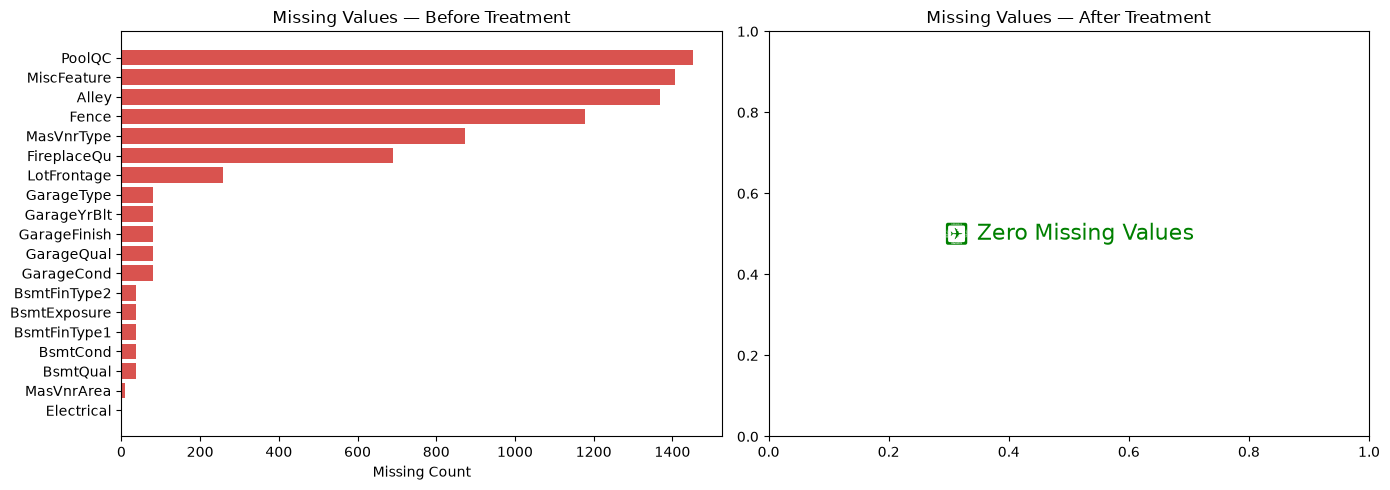

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)
axes[0].barh(missing_before.index, missing_before.values, color="#d9534f")
axes[0].set_title("Missing Values — Before Treatment")
axes[0].set_xlabel("Missing Count")
axes[0].invert_yaxis()

# After
missing_after = df_clean.isnull().sum()
missing_after = missing_after[missing_after > 0]
if len(missing_after) == 0:
    axes[1].text(0.5, 0.5, "✅ Zero Missing Values",
                 ha="center", va="center", fontsize=16,
                 color="green", transform=axes[1].transAxes)
    axes[1].set_title("Missing Values — After Treatment")
else:
    axes[1].barh(missing_after.index, missing_after.values, color="#d9534f")
    axes[1].set_title("Missing Values — After Treatment")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../reports/figures/missing_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

### Section 3 Summary

| Step | Treatment | Columns Affected |
|---|---|---|
| Drop >80% missing | Removed entirely | 4 |
| Absent categorical | Filled with `"None"` | 11 |
| Absent numeric | Filled with `0` | 10 |
| Truly missing categorical | Filled with mode | 8 |
| LotFrontage | Filled with neighbourhood median | 1 |

**Result:** Zero null values across all X remaining columns and 1,460 rows.

`df_clean` is now the working dataframe for all subsequent sections.

## Section 4 — Outlier Treatment

Outliers in house price data can severely distort model training.
We use two approaches:

1. **Manual removal** — Two extreme `GrLivArea` points flagged in the
   original Ames Housing paper by Dean De Cock himself. These are genuine
   data anomalies, not just high-value houses.

2. **Winsorization (IQR capping)** — For all other numeric columns,
   we cap extreme values at the 1.5×IQR boundary rather than dropping rows.
   Capping preserves the row count while limiting the influence of extremes.

We do NOT drop rows blindly — every removal is justified.

### Step 1 — Visualise GrLivArea vs SalePrice

Plotting above-ground living area against sale price to identify the
two extreme outliers flagged by Dean De Cock in his original paper.
These are large houses that sold for unusually low prices — likely
partial sales or non-market transactions.

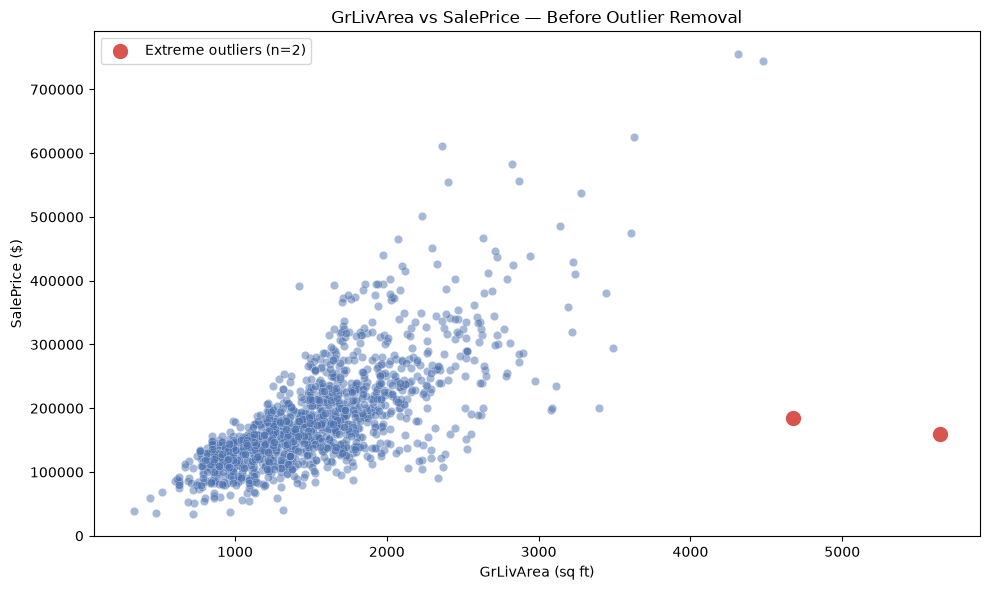

Extreme outlier rows:
      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_clean["GrLivArea"], df_clean["SalePrice"],
           alpha=0.5, color="#4C72B0", edgecolors="white", linewidths=0.3)

# Highlight the two extreme outliers
outliers = df_clean[(df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 200000)]
ax.scatter(outliers["GrLivArea"], outliers["SalePrice"],
           color="#d9534f", s=100, zorder=5, label=f"Extreme outliers (n={len(outliers)})")

ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("GrLivArea vs SalePrice — Before Outlier Removal")
ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/grlivarea_outliers_before.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Extreme outlier rows:")
print(outliers[["GrLivArea", "SalePrice"]].to_string())

### Step 2 — Remove GrLivArea Extreme Outliers

Removing the two rows where `GrLivArea > 4000` and `SalePrice < 200,000`.
These represent partial interest sales — not standard market transactions.
Including them would mislead the model into thinking large houses can sell cheaply.

Source: Dean De Cock, "Ames Iowa: Alternative to the Boston Housing Data Set" (2011)

In [28]:
rows_before = len(df_clean)

df_clean = df_clean[~((df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 200000))]
df_clean = df_clean.reset_index(drop=True)

rows_after = len(df_clean)

print(f"Rows before removal : {rows_before}")
print(f"Rows after removal  : {rows_after}")
print(f"Rows removed        : {rows_before - rows_after}")

Rows before removal : 1460
Rows after removal  : 1458
Rows removed        : 2


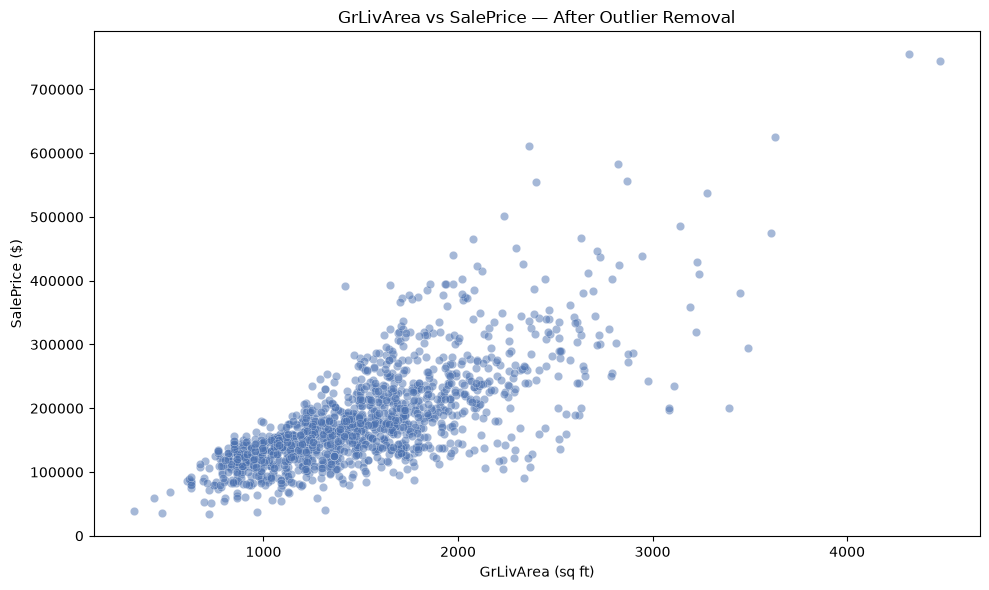

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_clean["GrLivArea"], df_clean["SalePrice"],
           alpha=0.5, color="#4C72B0", edgecolors="white", linewidths=0.3)

ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("GrLivArea vs SalePrice — After Outlier Removal")

plt.tight_layout()
plt.savefig("../reports/figures/grlivarea_outliers_after.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 3 — IQR-Based Outlier Detection on Numeric Columns

For all remaining numeric columns (excluding `Id`, `SalePrice`, `LogSalePrice`,
and the binary/ordinal columns that shouldn't be capped), we scan for outliers
using the IQR method.

**IQR Method:**
- Q1 = 25th percentile
- Q3 = 75th percentile
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Values beyond these bounds are **capped** (Winsorized) — not dropped.
Capping preserves all 1,458 rows while reducing extreme influence.

In [30]:
# Columns to exclude from IQR capping
exclude_from_capping = [
    "Id",
    "SalePrice",
    "MoSold",        # Month 1-12 — ordinal, no outliers
    "YrSold",        # Year — ordinal
    "YearBuilt",     # Year — capping would distort meaning
    "YearRemodAdd",  # Year — same reason
    "GarageYrBlt",   # Year — same reason
    "OverallQual",   # 1-10 scale — already bounded
    "OverallCond",   # 1-10 scale — already bounded
]

# Get numeric columns eligible for capping
numeric_to_cap = [
    col for col in df_clean.select_dtypes(include=["int64", "float64"]).columns
    if col not in exclude_from_capping
]

print(f"Columns eligible for IQR capping: {len(numeric_to_cap)}")
print(numeric_to_cap)

Columns eligible for IQR capping: 29
['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


### Step 4 — Apply Winsorization

In [31]:
capping_report = []

for col in numeric_to_cap:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_lower = (df_clean[col] < lower).sum()
    n_upper = (df_clean[col] > upper).sum()
    total_capped = n_lower + n_upper

    if total_capped > 0:
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        capping_report.append({
            "column": col,
            "lower_bound": round(lower, 2),
            "upper_bound": round(upper, 2),
            "capped_low": n_lower,
            "capped_high": n_upper,
            "total_capped": total_capped
        })

capping_df = pd.DataFrame(capping_report).sort_values("total_capped", ascending=False)

print(f"Columns where capping was applied: {len(capping_df)}")
print()
print(capping_df.to_string(index=False))

Columns where capping was applied: 27

       column  lower_bound  upper_bound  capped_low  capped_high  total_capped
EnclosedPorch         0.00         0.00           0          208           208
   BsmtFinSF2         0.00         0.00           0          167           167
  ScreenPorch         0.00         0.00           0          116           116
   MSSubClass       -55.00       145.00           0          103           103
   MasVnrArea      -245.62       409.38           0           97            97
  LotFrontage        30.00       110.00          46           45            91
 BsmtHalfBath         0.00         0.00           0           82            82
  OpenPorchSF      -102.00       170.00           0           75            75
 KitchenAbvGr         1.00         1.00           1           67            68
      LotArea      1461.25     17683.25           1           65            66
  TotalBsmtSF        43.00      2049.00          37           22            59
      MiscVal

### Step 5 — Visualise Capping Impact

Comparing distributions of the top 6 most-capped columns before and after
Winsorization to confirm the treatment is reasonable.

/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/1945052430.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 0].boxplot(before_vals, vert=False, patch_artist=True,
/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/1945052430.py:16: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 1].boxplot(after_vals, vert=False, patch_artist=True,
/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/1945052430.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i, 0].boxplot(before_vals, vert=False, patch_artist=True,
/var/folders/kn/3vj7m4_50vx23sfrjsvrbxqw0000gn/T/ipykernel_12294/1945052430.py:16: Mat

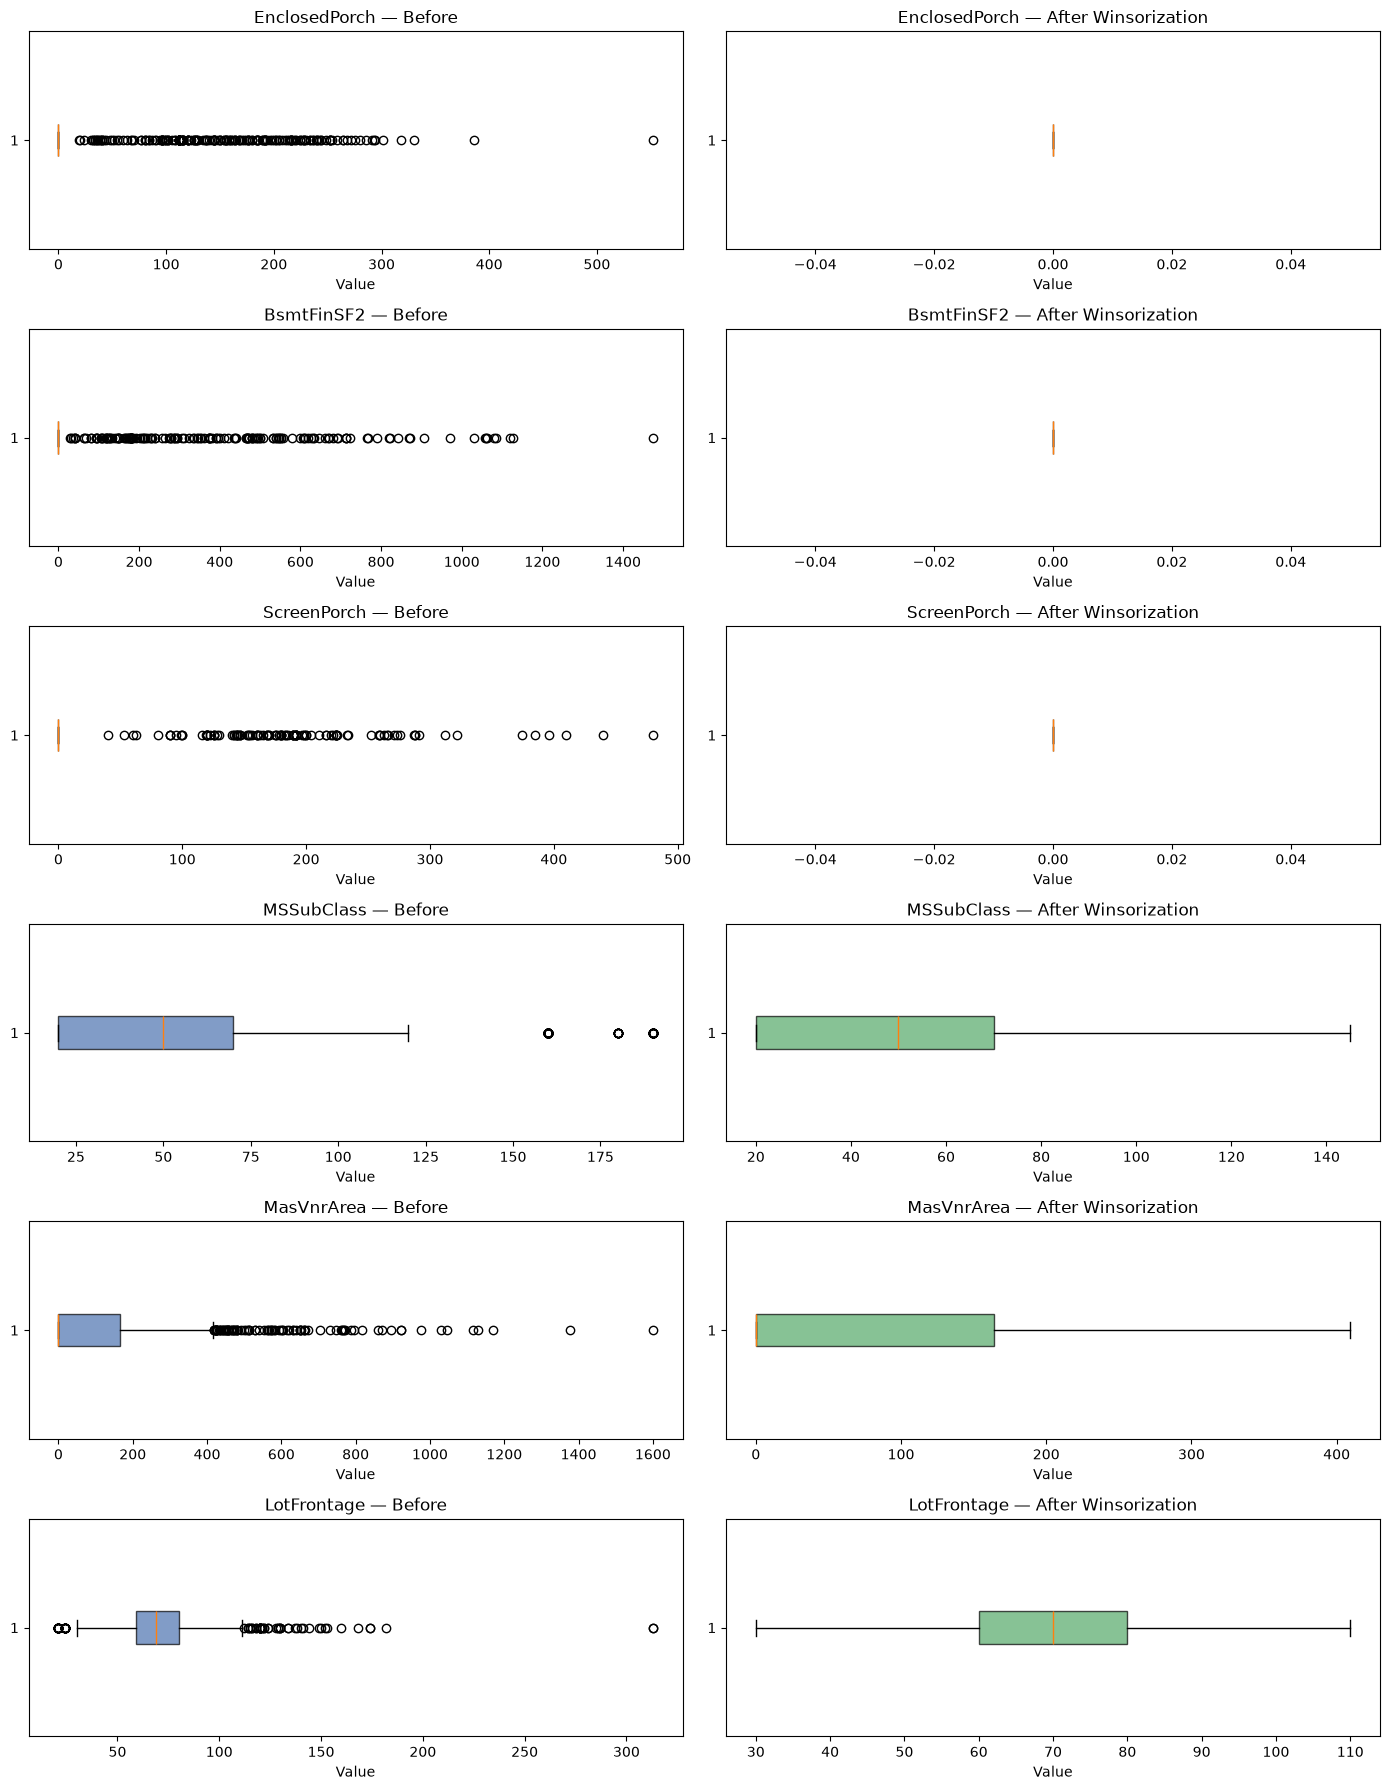

In [32]:
top_capped = capping_df.head(6)["column"].tolist()

if len(top_capped) > 0:
    fig, axes = plt.subplots(len(top_capped), 2, figsize=(14, len(top_capped) * 3))

    for i, col in enumerate(top_capped):
        # Before — use original df values for the same rows
        before_vals = df.loc[df_clean.index, col].dropna()
        after_vals = df_clean[col]

        axes[i, 0].boxplot(before_vals, vert=False, patch_artist=True,
                           boxprops=dict(facecolor="#4C72B0", alpha=0.7))
        axes[i, 0].set_title(f"{col} — Before")
        axes[i, 0].set_xlabel("Value")

        axes[i, 1].boxplot(after_vals, vert=False, patch_artist=True,
                           boxprops=dict(facecolor="#55A868", alpha=0.7))
        axes[i, 1].set_title(f"{col} — After Winsorization")
        axes[i, 1].set_xlabel("Value")

    plt.tight_layout()
    plt.savefig("../reports/figures/winsorization_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No columns required capping")

### Step 6 — Confirm No Nulls Introduced

In [33]:
nulls_after_capping = df_clean.isnull().sum().sum()

assert nulls_after_capping == 0, f"Capping introduced nulls: {nulls_after_capping}"

print(f"✅ Zero nulls after outlier treatment")
print(f"Final shape: {df_clean.shape}")
print(f"Rows removed (GrLivArea): {rows_before - rows_after}")
print(f"Columns with capping applied: {len(capping_df)}")

✅ Zero nulls after outlier treatment
Final shape: (1458, 77)
Rows removed (GrLivArea): 2
Columns with capping applied: 27


### Section 4 Summary

| Treatment | Method | Rows/Values Affected |
|---|---|---|
| GrLivArea extremes | Manual removal | 2 rows dropped |
| Numeric outliers | IQR Winsorization (1.5×) | 1448 values capped across 27 columns |

**Key decision:** Winsorization over dropping — preserves all remaining rows
while preventing extreme values from distorting model training.

Columns excluded from capping: year columns, bounded ordinal scales (1–10),
and the target variable `SalePrice`.